In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# load the dataset
df = pd.read_csv("global_pharmacy_sales_2020_2025_daily_dataset.csv")

In [4]:
# convert date into date format
df['date'] = pd.to_datetime(df['date'])

In [15]:
# arrange data by date
df = df.sort_values('date')

In [16]:
# get total sales for each day
daily_sales = df.groupby('date')['units_sold'].sum()

In [17]:
# moving average
# average sales of last 7 days
daily_sales_7 = daily_sales.rolling(7).mean()
# average sales of last 30 days
daily_sales_30 = daily_sales.rolling(30).mean()

In [18]:

# exponential smoothing
# gives more importance to recent sales
exp_smooth = daily_sales.ewm(span=7).mean()

In [19]:
# rolling statistics

# average of last 7 days
rolling_mean = daily_sales.rolling(7).mean()

# variation in last 7 days
rolling_std = daily_sales.rolling(7).std()

# lowest sales in last 7 days
rolling_min = daily_sales.rolling(7).min()

# highest sales in last 7 days
rolling_max = daily_sales.rolling(7).max()

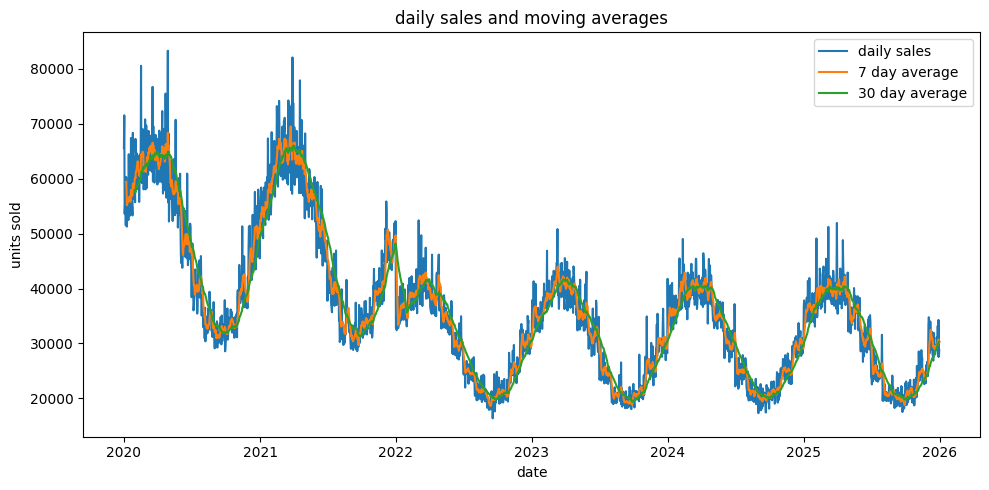

In [20]:
# moving averages
plt.figure(figsize=(10, 5))

plt.plot(daily_sales, label='daily sales')
plt.plot(daily_sales_7, label='7 day average')
plt.plot(daily_sales_30, label='30 day average')

plt.title('daily sales and moving averages')
plt.xlabel('date')
plt.ylabel('units sold')
plt.legend()

plt.tight_layout()
plt.show()

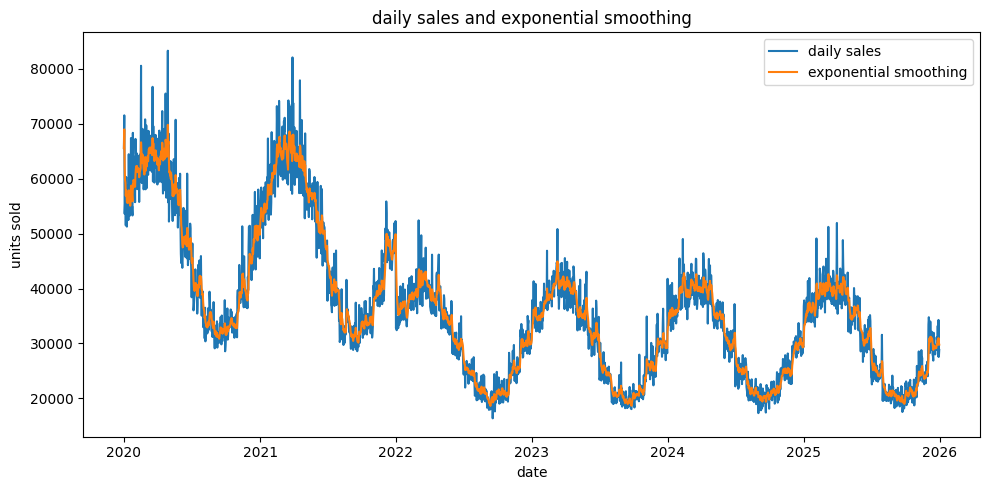

In [21]:
#exponential smoothing

plt.figure(figsize=(10, 5))

plt.plot(daily_sales, label='daily sales')
plt.plot(exp_smooth, label='exponential smoothing')

plt.title('daily sales and exponential smoothing')
plt.xlabel('date')
plt.ylabel('units sold')
plt.legend()

plt.tight_layout()
plt.show()

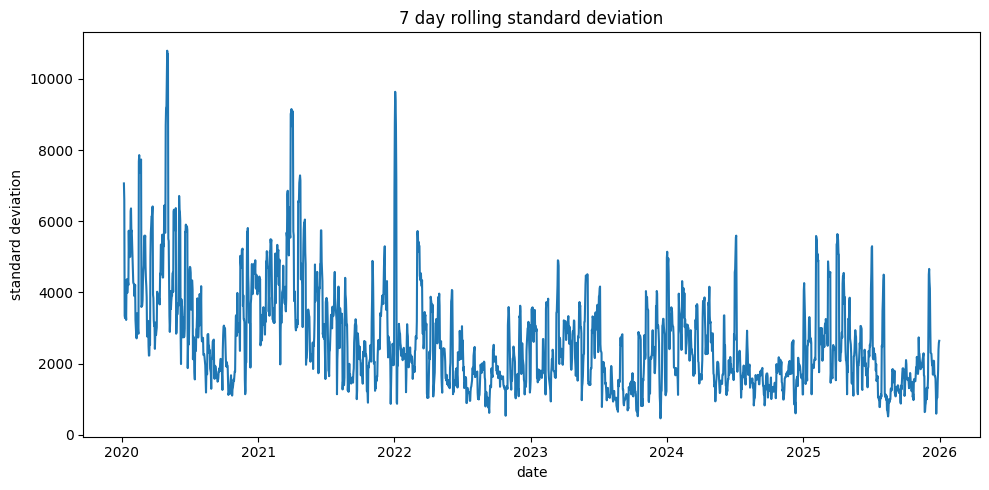

In [22]:
# plot rolling standard deviation

plt.figure(figsize=(10, 5))

plt.plot(rolling_std)

plt.title('7 day rolling standard deviation')
plt.xlabel('date')
plt.ylabel('standard deviation')

plt.tight_layout()
plt.show()

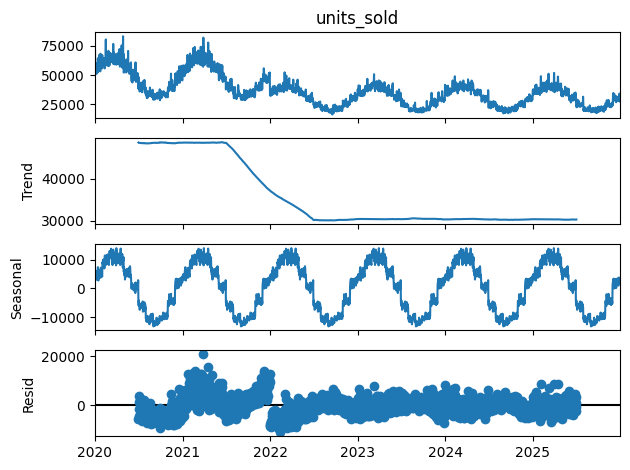

In [23]:
# trend and seasonality
# separate sales into trend, seasonality and residual
result = seasonal_decompose(
    daily_sales,
    model='additive',
    period=365
)

# show the decomposition graph
result.plot()

plt.tight_layout()
plt.show()

In [24]:
'''moving averages and rolling statistics help smooth the sales data.
exponential smoothing gives more importance to recent sales. 
trend shows the overall direction of sales, while seasonality shows repeated patterns. 
decomposition helps separate these patterns and makes pharmacy sales easier to understand.'''

'moving averages and rolling statistics help smooth the sales data.\nexponential smoothing gives more importance to recent sales. \ntrend shows the overall direction of sales, while seasonality shows repeated patterns. \ndecomposition helps separate these patterns and makes pharmacy sales easier to understand.'